In [113]:
import pandas as pd
import numpy as np
import os
from utils import assign_group,SME_load
import matplotlib.pyplot as plt

In [114]:
DATA_ROOT = "data/Scores/"

df = pd.read_csv(DATA_ROOT + "All_CV_scores.csv")
xgb_df = pd.read_csv(DATA_ROOT + "xgb_scores.csv")

In [115]:
# Separate dataframes based on Sample name pattern
ts_mask = df['Sample name'].str.contains(r'^\d+\s*-\s*\d+$', regex=True)
ts_df = df[ts_mask].copy()
final_products_df = df[~ts_mask].copy()
ts_df['time'] = ts_df['Sample name'].str[-2:].astype(int)

In [116]:
final_df = final_products_df.groupby('TS')[['Score_semi_sup_CV', 'Score', 'Score_unsup_CV']].mean()
final_df.reset_index(inplace=True)
final_df['Sample name'] = final_df['TS'].astype(str) + " - " + "10"
final_df['time'] = 10

In [117]:
final_df.head()

,TS,Score_semi_sup_CV,Score,Score_unsup_CV,Sample name,time
0,901,6.750707,6.75,8.672195,901 - 10,10
1,902,6.793161,7.25,8.650936,902 - 10,10
2,903,7.826547,8.00,8.602569,903 - 10,10
3,904,6.417146,6.50,8.614536,904 - 10,10
4,905,7.239125,7.75,8.604128,905 - 10,10


In [118]:
ts_df.head()

,Sample name,Score_unsup_CV,Score,TS,texture_unsup_CV,texture_real,Score_semi_sup_CV,time
36,901 - 0,7.684830,6,901,0,0,6.081683,0
37,901 - 2,6.374101,7,901,0,0,6.669625,2
38,901 - 4,6.966965,7,901,0,0,6.674101,4
39,901 - 6,7.038324,6,901,0,0,6.081683,6
40,901 - 8,7.044129,6,901,0,0,6.109143,8


In [119]:
df_scores = pd.concat([final_df,ts_df])
df_scores= df_scores.sort_values(['TS','time']).reset_index(drop=True).drop(columns=['texture_unsup_CV','texture_real'])

In [120]:
df_scores.head()

,TS,Score_semi_sup_CV,Score,Score_unsup_CV,Sample name,time
0,901,6.081683,6.0,7.684830,901 - 0,0
1,901,6.669625,7.0,6.374101,901 - 2,2
2,901,6.674101,7.0,6.966965,901 - 4,4
3,901,6.081683,6.0,7.038324,901 - 6,6
4,901,6.109143,6.0,7.044129,901 - 8,8


In [121]:
PROCESS_DATA_ROOT = "data/Extrusion/"
extrusion_df = pd.read_csv(PROCESS_DATA_ROOT + "Extruder_data_seconds.csv")


In [122]:
extrusion_group = extrusion_df.groupby('ts')
timeseries_data = {}

for name, df in extrusion_group:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df.set_index('Timestamp', inplace=True)
    df_mins = df.drop(columns=['group','kW','Comment','Time(s)']).resample('60S').mean()
    df_mins.reset_index(inplace=True)
    df_mins['Time(min)'] = np.arange(len(df_mins))
    df_mins['group'] = df_mins['ts'].apply(assign_group)
    timeseries_data[name] = df_mins


C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\3863006929.py:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_mins = df.drop(columns=['group','kW','Comment','Time(s)']).resample('60S').mean()
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\3863006929.py:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_mins = df.drop(columns=['group','kW','Comment','Time(s)']).resample('60S').mean()
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\3863006929.py:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_mins = df.drop(columns=['group','kW','Comment','Time(s)']).resample('60S').mean()
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\3863006929.py:7: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_mins = df.drop(columns=['group','kW','Comment','Time(s)']).resample('6

In [123]:
for name, df in timeseries_data.items():
    print(f"Shape of timeseries {name}: {df.shape}")
    df = df.iloc[:10]  # each experiment has 10 mins warmup which is not considered in the study
    df['Score_semi_sup_CV'] = np.nan
    df['Score_unsup_CV'] = np.nan 
    df['Score'] = np.nan
    timeseries_data[name] = df  

    
df_ts_temp = pd.concat(timeseries_data.values(), ignore_index=True)


Shape of timeseries 901: (23, 24)
Shape of timeseries 902: (28, 24)
Shape of timeseries 903: (23, 24)
Shape of timeseries 904: (20, 24)
Shape of timeseries 905: (18, 24)
Shape of timeseries 906: (22, 24)
Shape of timeseries 907: (14, 24)
Shape of timeseries 908: (12, 24)
Shape of timeseries 909: (18, 24)


C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2353561403.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Score_semi_sup_CV'] = np.nan
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2353561403.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Score_unsup_CV'] = np.nan
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2353561403.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [124]:
df_scores = df_scores[['Sample name','Score_semi_sup_CV','Score_unsup_CV','Score','TS' ,'time']]
ts_groups = df_scores.groupby(['TS'])
for ts, group in ts_groups:
    for index, row in group.iterrows():
        ts_name = int(row['TS'])
        if ts_name in timeseries_data:
                timeseries_data[ts_name].loc[timeseries_data[ts_name]['Time(min)'] == row['time'], 'Score_semi_sup_CV'] = row['Score_semi_sup_CV']
                timeseries_data[ts_name].loc[timeseries_data[ts_name]['Time(min)'] == row['time'], 'Score'] = row['Score']
                timeseries_data[ts_name].loc[timeseries_data[ts_name]['Time(min)'] == row['time'], 'Score_unsup_CV'] = row['Score_unsup_CV']
            
combined_df = pd.concat(timeseries_data.values(), ignore_index=True)
combined_df.head()


,Timestamp,Temp Downspout,Temp Zone 1,Temp Zone 2,Temp Zone 3,Temp Zone 4,Die Temp,Bin Feeder RPM,Extruder Load,Extruder RPM,...,WHC,In-barrel MC,Time(min),SME-Load,SME-Watt,Raw Material Moisture,group,Score_semi_sup_CV,Score_unsup_CV,Score
0,2024-01-01 00:00:00,25.934426,28.989377,49.912297,78.835595,106.483526,148.732399,13.897628,31.504617,356.938846,...,272.2,0.29726,0,206.235123,726.671738,0.082974,FBC + PPI + SPC,6.081683,7.684830,6.0
1,2024-01-01 00:01:00,25.936662,28.990393,49.912298,82.283735,101.316310,148.897792,14.026053,31.646530,356.847088,...,272.2,0.29726,1,206.182107,732.122855,0.082974,FBC + PPI + SPC,NaN,NaN,NaN
2,2024-01-01 00:02:00,25.937068,28.992832,49.913313,82.272762,101.082489,148.822816,14.135818,31.681069,356.822471,...,272.2,0.29726,2,206.167883,733.808524,0.082974,FBC + PPI + SPC,6.669625,6.374101,7.0
3,2024-01-01 00:03:00,25.936255,28.989784,49.040807,77.884405,103.229334,148.066155,14.265381,31.793624,356.936608,...,272.2,0.29726,3,206.233830,738.350468,0.082974,FBC + PPI + SPC,NaN,NaN,NaN
4,2024-01-01 00:04:00,25.934833,28.991409,48.917469,79.041845,104.946119,147.337533,14.385841,32.017923,356.926377,...,272.2,0.29726,4,206.227919,750.559883,0.082974,FBC + PPI + SPC,6.674101,6.966965,7.0


In [125]:
from darts import TimeSeries
from darts.dataprocessing.transformers import MissingValuesFiller

filled_timeseries_data = {}
value_cols = ['Score_semi_sup_CV','Score_unsup_CV','Score']
for ts_name, df in timeseries_data.items():
    
    ts = TimeSeries.from_dataframe(df, time_col='Time(min)', value_cols=value_cols)
    
    filler = MissingValuesFiller()
    ts_filled = filler.transform(ts)
    df_filled = ts_filled.pd_dataframe()
    print(df_filled)
    df['Score_semi_sup_CV'] = df_filled['Score_semi_sup_CV']
    df['Score_unsup_CV'] = df_filled['Score_unsup_CV']
    df['Score'] = df_filled['Score']

    df['ts'] = ts_name
    
    filled_timeseries_data[ts_name] = df

combined_df_filled = pd.concat(filled_timeseries_data.values(), ignore_index=True)



C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2635865958.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Score_semi_sup_CV'] = df_filled['Score_semi_sup_CV']
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2635865958.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Score_unsup_CV'] = df_filled['Score_unsup_CV']
C:\Users\amirbg\AppData\Local\Temp\ipykernel_40700\2635865958.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

component  Score_semi_sup_CV  Score_unsup_CV  Score
Time(min)                                          
0                   6.081683        7.684830    6.0
1                   6.375654        7.029465    6.5
2                   6.669625        6.374101    7.0
3                   6.671863        6.670533    7.0
4                   6.674101        6.966965    7.0
5                   6.377892        7.002645    6.5
6                   6.081683        7.038324    6.0
7                   6.095413        7.041226    6.0
8                   6.109143        7.044129    6.0
9                   6.109143        7.044129    6.0
component  Score_semi_sup_CV  Score_unsup_CV  Score
Time(min)                                          
0                   6.203516        6.570228    6.0
1                   6.142599        6.694960    6.0
2                   6.081683        6.819692    6.0
3                   6.095413        6.812081    6.0
4                   6.109143        6.804469    6.0
5           

In [126]:
combined_df_filled['ts'] = combined_df_filled['ts'].astype(int)
combined_df_filled['group'] = combined_df_filled['ts'].apply(assign_group)

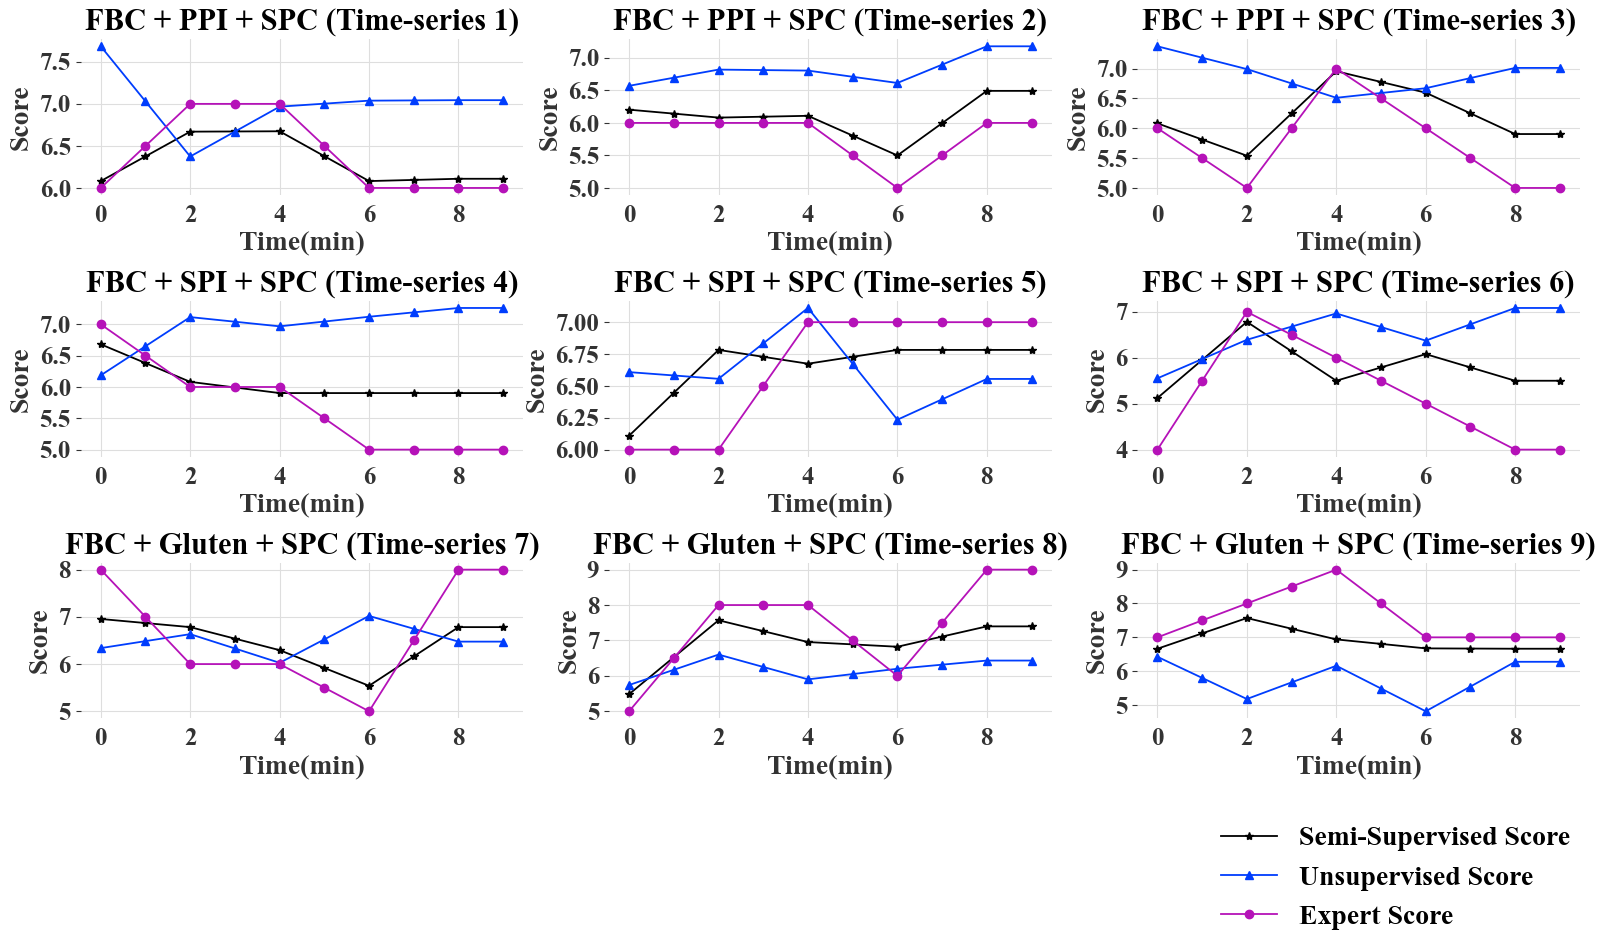

In [ ]:
plt.rcParams['font.family'] = 'Times New Roman'
fig, axes = plt.subplots(3, 3, figsize=(16, 8))

groups = ["FBC + PPI + SPC", "FBC + SPI + SPC", "FBC + Gluten + SPC"]

for row, group in enumerate(groups):
    group_data = combined_df_filled[combined_df_filled['group'] == group]
    
    timeseries = sorted(group_data['ts'].unique())
    
    for col, ts in enumerate(timeseries):
        ax = axes[row, col]
        ts_data = group_data[group_data['ts'] == ts]
        
        ax.plot(ts_data['Time(min)'], ts_data['Score_semi_sup_CV'], marker='*', label='Semi-Supervised Score')
        ax.plot(ts_data['Time(min)'], ts_data['Score_unsup_CV'], marker='^', label='Unsupervised Score')
        ax.plot(ts_data['Time(min)'], ts_data['Score'], marker='o', label='Expert Score')
        
        ax.set_title(f'{group} (Time-series {ts-900})', fontweight='bold',fontsize=22)
        ax.set_xlabel('Time(min)',fontsize=20)
        ax.set_ylabel('Score',fontsize=20)
        ax.grid(True)
        
        ax.tick_params(axis='both', which='major')
        for tick in ax.get_xticklabels():
            tick.set_fontweight('bold')
            tick.set_fontsize(18)
        for tick in ax.get_yticklabels():
            tick.set_fontweight('bold')
            tick.set_fontsize(18)

            
        

handles, labels = axes[2,2].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(1, -0.20), prop={'weight': 'bold','size':20})

plt.tight_layout()
plt.show()


In [129]:
combined_df_filled.to_csv('../PART3 - Multimodal/data/multimodal_data.csv', index=False)
